# Chapter 10: plotting with matplotlib

Matplotlib is one of several modules that provide plotting functions for python. It is the most commonly used in mathematics and data science. 

`matplotlib` can do many things, from quick graphs to full-blown graphical user interface and interactive web apps. We focus on the `pyplot` component commonly used to produce mathematical figures. You load pyplot with 
```
import matplotlib.pyplot as plt
```
Just like it is customary to use `np` as the prefix for `numpy`, most people use `plt` instead of `pyplot`.


`matplotlib` can interact with jupyter notebooks (remember that jupyter is only one way to use python) through *matplotlib magic* and specific drivers. We won't go into the details. Just remember to add the command `%matplotlib ipympl` or `%matplotlib widget` at the beginning of your notebook. 

matplotlib has tons of documentation at http://matplotlib.org, and many online tutorials.

## 10.1 figures, axes, etc
Say we want draw the graph of a function $f$ on an inteval $(a,b)$, we can generate a ndarray of `x` values using `np.linspace`, plot point with coordinates $(X, f(X))$ and connect the points with lines. 

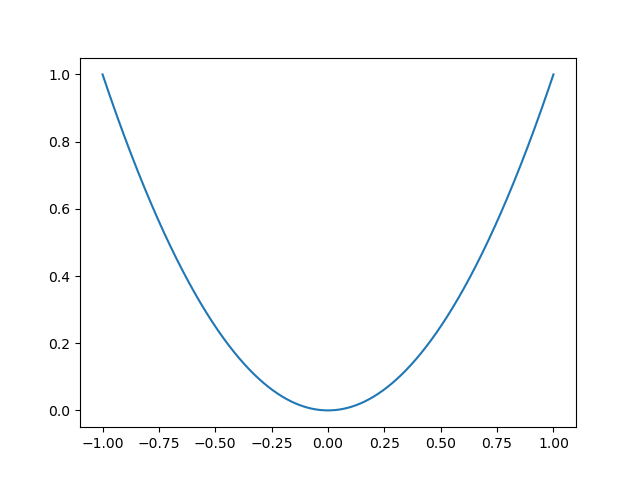

In [9]:
import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np

# left endpoint
a = -1
# right endpoint
b = 1
# number of points in between
n = 1000

X = np.linspace(a, b, n)
# using NumPy vectorization 
f = lambda x : x**2
Y = f(X)

fig = plt.figure()
ax  = plt.axes()
p1  = ax.plot(X, Y)

Here, we created a *Figure*. Think of a figure as a blank page in which we may want to draw one or several graphs. In matplotlib lingo, each of these graphs are called *Axes*. We created a single Axes object `ax` which fills the whole figure, but a Figure may contain several axes. 

in `ax`, we created a plot, `p1`which is a list of `matplotlib.lines.Line2D` objects. 


The full hierarchy of objects in a figure is shown in this figure from matplotlib documentation
![](https://matplotlib.org/stable/_images/sphx_glr_anatomy_001_2_00x.png)

It gives us some ideas of what we can do to change the appearance of our plot.

In [ ]:
t = ax.set_title('A simple plot')
x = ax.set_xlabel(r'$x$')
y = ax.set_ylabel(r'$y$')

def g(x: float) -> float:
    return 2-x**2
p2 = ax.plot(X,g(X))
ax.grid()
plt.show()

Notice that the changes are applied back in the figure we created. This makes sense, we created `fig`, added `ax` to it and are not adding plots of `ax`. It is good practive to *close* the figure once we are done with it. Typically, matplotlib has a 20 open figures limit. 

In [ ]:
plt.close(fig)

The process to open a new figure can be shortened a little using `plt.subplot`:

In [ ]:
fig, ax = plt.subplots()
p1 = ax.plot(X,f(X))
p2 = ax.plot(X,g(X))

In [ ]:
plt.close(fig)

Using `plt.subplots`, we can easily create figures containig several plots (*i.e.* several `Axes`). 

In [ ]:
fig, axes = plt.subplots(1, 2)
p1 = axes[0].plot(X,f(X))
p2 = axes[1].plot(X,g(X))

In [ ]:
# adding more rows 
fig, axes = plt.subplots(2, 2)
p1 = axes[0,0].plot(X,f(X))
p2 = axes[1,0].plot(X,g(X))
p3 = axes[0,1].plot(X,g(X))
p4 = axes[1,1].plot(X,f(X))

In [ ]:
plt.close('all')

## 10.2 Some commonly used plotting functions:

* `plt.plot`: 2D line plot
* `plt.scatter`: 2D points cloud
* `plt.bar`: 2D bar plot (vertical)
* `plt.barh`: 2D bar plot (horizontal)
* `plt.imshow`: display a 2D array of numbers (or RGB values) as an image
* `plt.quiver`: draw arrows in 2D

All of these have too many options to list. `help(function)` and `?function` are your friends.

In [ ]:
fig, ax = plt.subplots(1, 2)
X = np.linspace(0,np.pi,101)
X1 = np.linspace(0,np.pi,21)

p0 = ax[0].plot(X,np.sin(X))
p1 = ax[1].scatter(X1, np.cos(X1))

In [ ]:
plt.close(fig)

We can also simply plot a 2D-array as an image!

In [ ]:
X = np.eye(100)

plt.imshow(X)
plt.show()

A more interesting array!

In [ ]:
fig, ax = plt.subplots()
nrow = 101
ncol = 201
X = np.linspace(0,2*np.pi, nrow)
Y = np.linspace(0,2*np.pi, ncol)
data2D = np.empty((nrow,ncol))

for i in range(nrow):
    for j in range(ncol):
        data2D[i,j] = np.cos(2*X[i]) * np.sin(3*Y[j])
p1 = ax.imshow(data2D)


In [ ]:
plt.close('all')

In [ ]:
grades = np.loadtxt('grades.csv', skiprows = (1), usecols = (9), delimiter = ',')
print(grades)

In [ ]:
grades = np.loadtxt('grades.csv', skiprows = (1), usecols = (9), delimiter = ',')

plt.hist(grades, bins=10, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Grade')
plt.ylabel('Frequency')
plt.title('Distribution of Student Grades')

# Display the plot
plt.show()

# Tuesday March 10th 2026

## Last time 
- Finishing up Numpy libraries: Polynomials.
    - Numpy's polynomial library provides a nice interface for working with polynomials. Implementing arithmetic on polynomials and some other common tools, such as polynomial interpolation.
    - Lagrange interpolation: An algorithm for giving a unique interpolating polynomial for a collection of $n$ data points.
- Intro to plotting with Matplotlib

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 10.3 Legends, line styles, etc

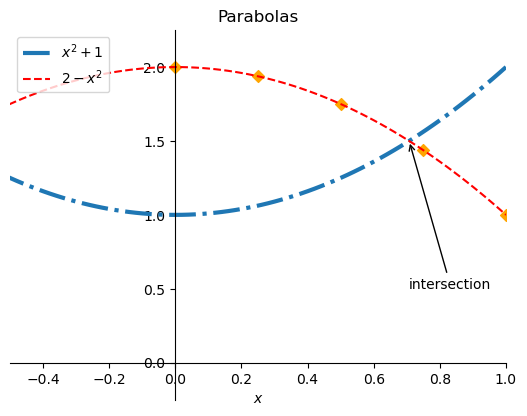

In [2]:

def f(x: float) -> float:
    return x**2+1
def g(x: float) -> float:
    return 2-x**2
    
X = np.linspace(-1,1,101)
fig, ax = plt.subplots()
p1 = plt.plot(X,f(X), linewidth=3, label = r'$x^2+1$')
#linestyle = 'dashdot' makes a line atlernating between dashes and dots
p1[0].set_linestyle('dashdot')
# linestyle = '--' makes a dashed line
p2 = plt.plot(X,g(X), color = 'red', linestyle = '--', label = r'$2-x^2$')
ax.set_title('Parabolas')
ax.set_xlabel(r'$x$')
ax.set_xlim(-0.5,1)
ax.set_ylim(-0.25,2.25)

#usually we call spines "axes" when we speak mathematically
# However, spines can be set anywhere (not only in the traditional
# locations of the x and y axes.)
ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left')

X = np.linspace(0,1,5)
#marker='D' sets the point marker to diamond.
p3 = ax.scatter(X,g(X), marker='D', color = 'orange')

x0 = np.sqrt(2)/2
a1 = ax.annotate('intersection', (x0, g(x0)), xytext = (x0,0.5), arrowprops = {'arrowstyle': '->'})

## 10.4 Illustrating some mathematical concepts
### Tangent line as the limit of the secant line

Text(0, 0.5, '$y$')

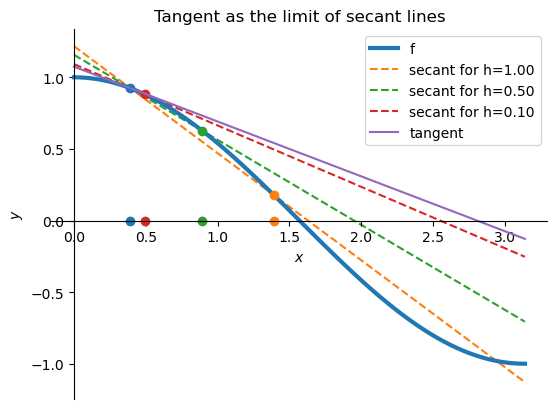

In [3]:
fig, ax = plt.subplots()

# we will start with cos x from 0 to pi
def f(x):
    return np.cos(x)
def fp(x):
    return -np.sin(x)
    
X = np.linspace(0,np.pi, 101) 
ax.plot(X,f(X), linewidth=3,label = 'f')
x0 = np.pi/8
plt.scatter([x0]*2,[0,f(x0)])
for h in [1, 0.5, 0.1]:
    plt.plot(X, f(x0) + (f(x0+h) - f(x0))/h * (X-x0),label = f'secant for h={h:.2f}', linestyle='--',zorder = 0)
    plt.scatter([x0+h]*2, [0,f(x0+h)], marker='o',zorder = 2)
s = ax.plot(X,f(x0) + fp(x0) * (X-x0), label='tangent', linestyle='-')
ax.legend()
ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Tangent as the limit of secant lines')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

### Definite integrals and area under the curve

Text(0, 0.5, '$y$')

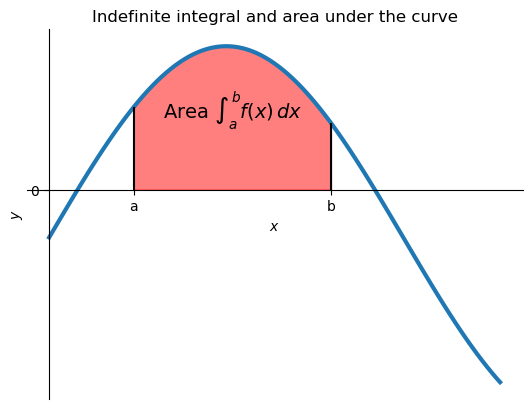

In [5]:
plt.close('all')
fig, ax = plt.subplots()
def f(x):
    return np.sin(x)-0.25
    
a = 0.75
b = 2.5

X = np.linspace(0,4, 101) 
ax.plot(X,f(X), linewidth=3,label = 'f')

I = np.linspace(a,b,101)
ax.fill_between(I,f(I),color='red', alpha=.5)
ax.vlines([a,b],[0,0], [f(a),f(b)],color='black')
ax.text((a+b)/2, f((a+b)/2)/2,r"Area $\int_a^b f(x)\, dx$", fontsize = 14, horizontalalignment = 'center')
ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks([a,b],['a','b'])
ax.set_yticks([0], [0])
ax.set_title('Indefinite integral and area under the curve')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

### Riemann sums

Text(0, 0.5, '$y$')

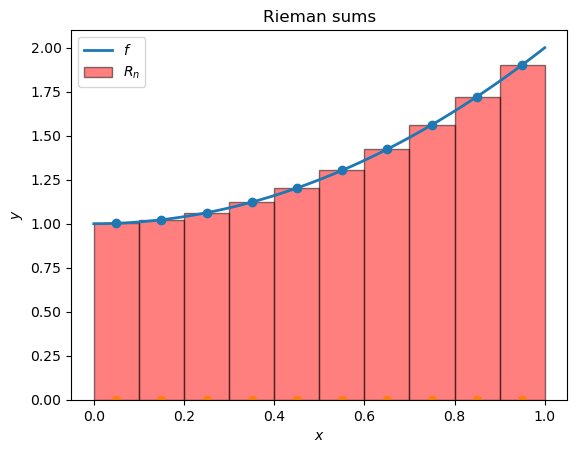

In [4]:
## Rieman summs
def f(x):
    return 1+x**2

fig, ax = plt.subplots()
n = 101
X = np.linspace(0,1,n)
ax.plot(X,f(X),lw=2,label='$f$')

ni = 11
Xi = np.linspace(0,1,ni)
Xis = (Xi[:-1]+Xi[1:])/2
ax.bar(Xi[:-1],f(Xis),width = 1/(ni-1),alpha=0.5,label = '$R_n$', align='edge',edgecolor='k',color='r')
ax.scatter(Xis,f(Xis))
ax.scatter(Xis,np.zeros(np.shape(Xis)))

ax.legend()
ax.set_title('Rieman sums')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

### Application to differential equations - Direction Field Plots

In the sciences, complex systems are often described (approximated) by differential equations. It is often difficult, if not impossible, to solve the equations exactly. 

However, we may use graphical tools to gain useful insight into how differential equations behave without solving them directly, or even approximating their solutions.

#### Direction Fields

We can gain knowledge about the long-term behaviour of a differential equation for multiple choices of initial values by constructing its associated vector field. The idea is to graph the direction and size of the derivative for every point on a plane.

#### Example

Draw the vector field and describe the long term evolution of the following equation 
$$y'=(y^2-y-2)(1-y)^2.$$

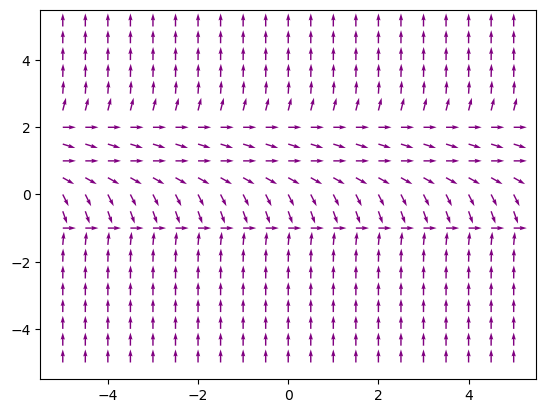

In [5]:
x = np.arange(-5,5.5,0.5) # x-axis goes from -5 to 5 with step size 0.5
y = np.arange(-5,5.5,0.5) # y-axis is drawn the same as the x-axis
X,Y = np.meshgrid(x,y) # create a grid of all (x,y) points in the above ranges

dy = (Y**2-Y-2)*(1-Y)**2 # plot y-derivative
dx = np.ones_like(dy) # since x is just the function x, its derivative is 1.
norm = np.sqrt(dx**2+dy**2) # normalize derivatives
dyu = dy/norm
dxu = dx/norm

plt.quiver(X,Y,dxu,dyu,color = "purple") # quiver allows us to plot a vector field
plt.show()

We can obtain the following information from the above plot:
- There are four long term behaviours of the system. Corresponding to the following initial conditions:
    - $y=\infty$
    - $y=2$
    - $y=1$
    - $y=-1$
- $y=-1$ is the only **stable** equilibrium (initial conditions close to $y=1$ will converge to this solution).

# Example 
Draw the vector field and describe the long term evolution of the following equation:
$$y'=y-x$$

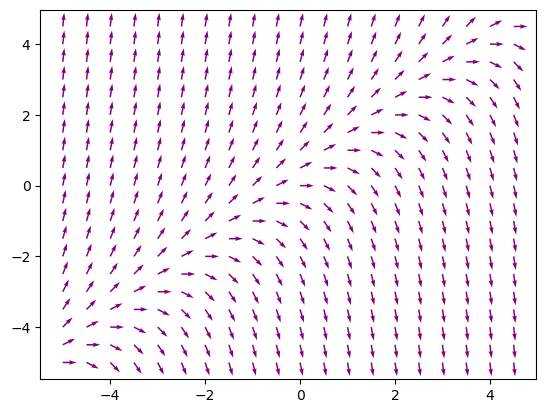

In [6]:
import numpy as np
import matplotlib.pyplot as plt


x = np.arange(-5,5,0.5)
y = np.arange(-5,5,0.5)
X,Y = np.meshgrid(x,y)

dy = Y - X
dx = np.ones_like(dy)
norm = np.sqrt(dx**2+dy**2)
dyu = dy/norm
dxu = dx/norm

plt.quiver(X,Y,dxu,dyu,color = "purple")
plt.show()

## Animations

In [7]:
import matplotlib.animation as animation

/opt/anaconda3/envs/1mp3/lib/python3.13/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


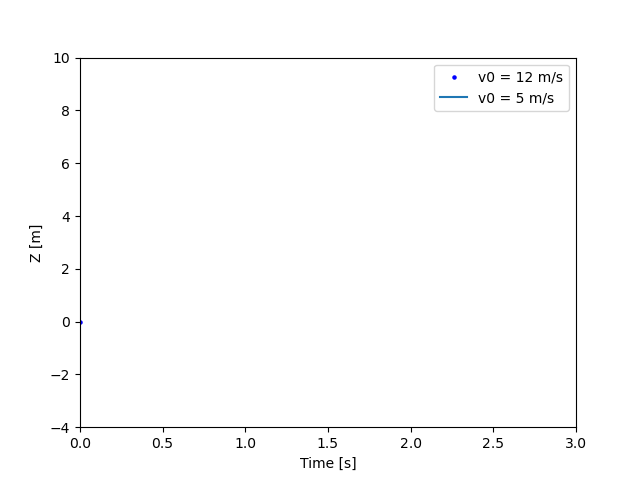

In [10]:
fig, ax = plt.subplots()
t = np.linspace(0, 3, 40)
g = -9.81
v0 = 12
z = g * t**2 / 2 + v0 * t

v02 = 5
z2 = g * t**2 / 2 + v02 * t

scat = ax.scatter(t[0], z[0], c="b", s=5, label=f'v0 = {v0} m/s')
line2 = ax.plot(t[0], z2[0], label=f'v0 = {v02} m/s')[0]
ax.set(xlim=[0, 3], ylim=[-4, 10], xlabel='Time [s]', ylabel='Z [m]')
ax.legend()


def update(frame):
    # for each frame, update the data stored on each artist.
    x = t[:frame]
    y = z[:frame]
    # update the scatter plot:
    data = np.stack([x, y]).T
    scat.set_offsets(data)
    # update the line plot:
    line2.set_xdata(t[:frame])
    line2.set_ydata(z2[:frame])
    return (scat, line2)


ani = animation.FuncAnimation(fig=fig, func=update, frames=40, interval=30)
plt.show()

### Conway's Game of Life

A zero player game invented by the great mathematician John Conway in 1970. It proceeds by randomly populating an array with $0$s and $1$s. We will call cells containing a $1$ alive and cells containing a $0$ dead. The game progresses by the following rules:
1. Any live cell with fewer than two live neighbours dies, as if by underpopulation.
2. Any live cell with two or three live neighbours lives on to the next generation.
3. Any live cell with more than three live neighbours dies, as if by overpopulation.
4. Any dead cell with exactly three live neighbours becomes a live cell, as if by reproduction.

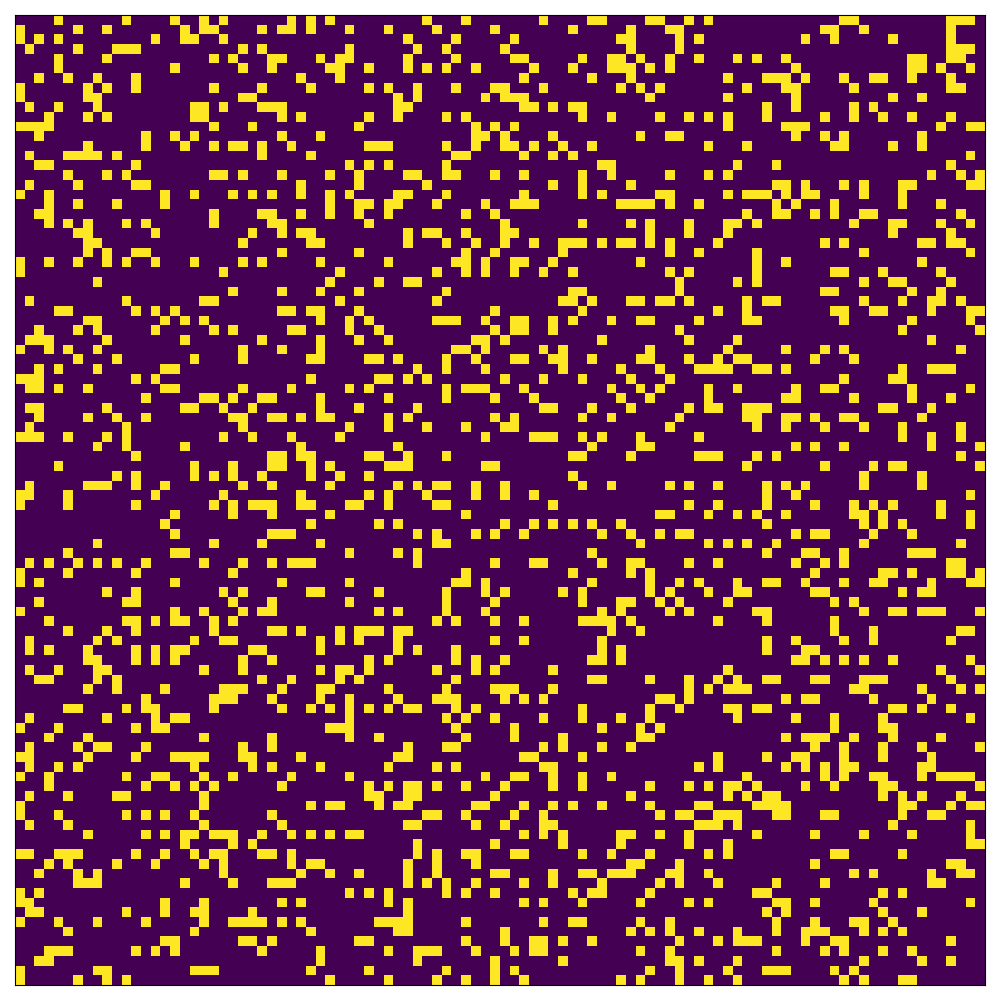

In [11]:
import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np

grid, grid_size, img_plot = None, None, None

def initialize(size):
    grid = np.random.choice([0, 1], size * size, p=[0.8, 0.2]).reshape(size, size)
    return grid

def conway_step(frame):
    global grid, grid_size, img_plot
    new_grid = np.zeros_like(grid)
    for x in range(grid_size):
        for y in range(grid_size):
            # this is the trickiest line
            # we use % grid_size to deal with how to count 
            # neighbors of elements on the edges. We use the "Pacman" way of associating
            # neighbors to cells on the edges (i.e. lefthand side wraps around to the right
            # and top wraps around to the bottom).
            total = sum(
                [grid[(x + i) % grid_size, (y + j) % grid_size] for i in range(-1, 2) for j in range(-1, 2)])
            if grid[x, y] == 1 and total - 1 in (2, 3):
                new_grid[x, y] = 1
            elif grid[x, y] == 0 and total == 3:
                new_grid[x, y] = 1
            else:
                new_grid[x, y] = 0
    grid = new_grid
    img_plot.set_data(new_grid)
    return img_plot,

def conway(size=100):
    global grid, grid_size, img_plot
    grid_size = size
    grid = initialize(size)
    fig, ax = plt.subplots(figsize=(10, 10))
    img_plot = ax.imshow(grid, interpolation='nearest')
    ax.set_xticks([])
    ax.set_yticks([])
    ani = animation.FuncAnimation(fig, frames=1000, func=conway_step, interval=100)
    plt.tight_layout()
    plt.show()
    return ani

conway(size=100)
